In [1]:
print("hello")

hello


Source: https://www.certara.com/blog/key-properties-in-drug-design-predicting-lipophilicity-pka-and-solubility/

# Dataset Exploration: Lipophilicity
want to understand the raw data 

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
!pip install matplotlib

In [8]:
url = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/Lipophilicity.csv"
df = pd.read_csv(url)
df.head()

,CMPD_CHEMBLID,exp,smiles
0,CHEMBL596271,3.54,Cn1c(CN2CCN(CC2)c3ccc(Cl)cc3)nc4ccccc14
1,CHEMBL1951080,-1.18,COc1cc(OC)c(cc1NC(=O)CSCC(=O)O)S(=O)(=O)N2C(C)...
2,CHEMBL1771,3.69,COC(=O)[C@@H](N1CCc2sccc2C1)c3ccccc3Cl
3,CHEMBL234951,3.37,OC[C@H](O)CN1C(=O)C(Cc2ccccc12)NC(=O)c3cc4cc(C...
4,CHEMBL565079,3.10,Cc1cccc(C[C@H](NC(=O)c2cc(nn2C)C(C)(C)C)C(=O)N...


here 
CMPD_CHEMBLID: A unique id for each compound from the ChEMBL database.
smiles: molecular structure as text string 
exp : is logP value that need to be predicted 
high logP means prefer oil or fat over water 

In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print()
print(df.info())

Rows: 4200
Columns: 3

<class 'pandas.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CMPD_CHEMBLID  4200 non-null   str    
 1   exp            4200 non-null   float64
 2   smiles         4200 non-null   str    
dtypes: float64(1), str(2)
memory usage: 343.7 KB
None


The `exp` column is a float (continuous number), which confirms this is a 
regression problem, not classification.
No missing values found in any column.
This is clean data — no imputation or row dropping needed before training.


In [10]:
df['exp'].describe()

count    4200.000000
mean        2.186336
std         1.203004
min        -1.500000
25%         1.410000
50%         2.360000
75%         3.100000
max         4.500000
Name: exp, dtype: float64

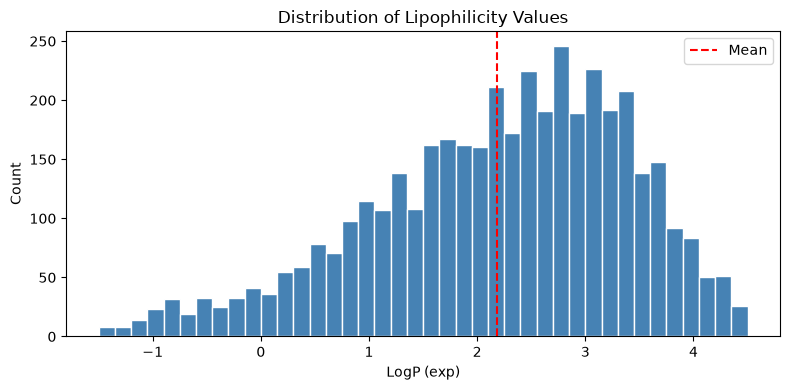

In [11]:
plt.figure(figsize=(8, 4))
plt.hist(df['exp'], bins=40, color='steelblue', edgecolor='white')
plt.xlabel("LogP (exp)")
plt.ylabel("Count")
plt.title("Distribution of Lipophilicity Values")
plt.axvline(df['exp'].mean(), color='red', linestyle='--', label='Mean')
plt.legend()
plt.tight_layout()
plt.show()

The distribution looks roughly bell-shaped

In [12]:
print("Sample SMILES strings:")
for smiles in df['smiles'].sample(5, random_state=42):
    print(smiles)

Sample SMILES strings:
Clc1ccc2NC(=O)CN(C(c3ccccc3)c2c1)C(=O)c4occc4
CCCNC[C@H](O)COc1ccccc1C(=O)CCc2ccccc2
CNc1cccc(CCCc2ccc(C[C@H](NC(=O)c3c(Cl)cccc3Cl)C(=O)O)s2)n1
CC1(C)CNC(=O)c2sc(nc2C1)N3CCOCC3
C[C@@](O)(C(=O)Nc1ccc(cc1Cl)S(=O)(=O)NCC=C)C(F)(F)F


 strings encode the molecular structure of each compound.